# SIS avec matrices de contagion locales par crise

Jusqu'ici les quatre matrices de contagion (PMFG, VAR(1), VAR(13), Corr thr)
étaient construites **une fois sur toute la période 2019-2023**. Ici, pour
chaque crise détectée, on reconstruit les quatre matrices sur la fenêtre
**[début de crise − 1 mois, fin de crise + 1 mois]** (±21 jours de bourse),
puis on refait les fits SIS ↔ E_i de la crise avec ces matrices *locales*.

Les conditions initiales (E_i mesuré, x0, nombre de jours) sont **réutilisées
telles quelles** depuis le cache `period_data` — elles ne dépendent pas de la
matrice — donc la comparaison locale vs pleine période est à conditions
strictement identiques. Seule la matrice A change.

In [1]:
import os, sys, warnings
sys.path.insert(0, 'code')
os.environ["PYTHONPATH"] = os.path.abspath('code') + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.stats import linregress

import config, pipeline, sis
from data import build_context
from networks import build_pmfg, fit_var, prepare_for_sis, build_filtered_corr
from cache import disk_cache, sig_of
from periods import asset_runs

warnings.filterwarnings("ignore")

ctx = build_context()
per = pipeline.load_periods(ctx)
intervals = per["intervals_chrono"]
crisis_map = per["crisis_map"]
period_data = pipeline.fit_main(ctx, intervals, crisis_map)["period_data"]

fmt = lambda pa, pb: f"{ctx.all_days[pa]:%d/%m/%y}-{ctx.all_days[pb]:%d/%m/%y}" \
    if hasattr(ctx.all_days[pa], 'strftime') else f"{ctx.all_days[pa]} → {ctx.all_days[pb]}"
labels = {(pa, pb): f"{ctx.all_days[pa]} → {ctx.all_days[pb]}" for (pa, pb) in intervals}
print(f"{len(intervals)} crises détectées :")
for (pa, pb) in intervals:
    print(f"  {labels[(pa, pb)]}   ({pb - pa + 1} jours)")

N = 146 actifs, T = 13360 obs ; 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
[cache] OK  base
1031 jours ; <|C_ij|> moyen = 0.4686
[cache] OK  crisis_map
[cache] OK  period_data
24 crises détectées :
  2019-04-01 → 2019-05-13   (30 jours)
  2019-07-16 → 2019-08-05   (15 jours)
  2019-09-11 → 2019-10-11   (23 jours)
  2019-10-30 → 2019-12-03   (24 jours)
  2019-12-19 → 2020-03-09   (54 jours)
  2020-05-28 → 2020-06-12   (12 jours)
  2020-08-06 → 2020-09-21   (32 jours)
  2020-10-13 → 2020-10-28   (12 jours)
  2020-12-02 → 2020-12-21   (14 jours)
  2020-12-31 → 2021-01-27   (18 jours)
  2021-02-09 → 2021-03-01   (14 jours)
  2021-03-23 → 2021-05-19   (41 jours)
  2021-06-29 → 2021-07-19   (14 jours)
  2021-08-10 → 2021-10-07   (42 jours)
  2021-11-02 → 2021-12-01   (21 jours)
  2021-12-28 → 2022-01-25   (20 jours)
  2022-02-01 → 2022-02-28   (19 jours)
  2022-04-14 → 2022-05-06   (16 jours)
  2022-05-25 → 2022-06-13   (13 jours)
  2022-08-03 → 2022-10-04   (44 jours)
  2022-10-26 → 2022-11

## 1. Matrices locales et fits SIS

`local_matrices` reconstruit les quatre réseaux sur la tranche de données
étendue (crise ± 21 jours de bourse), exactement comme `data.py` le fait sur la
pleine période (mêmes `build_pmfg`, `fit_var`, `build_filtered_corr`,
`prepare_for_sis`, même seuil `CORR_THRESHOLD`). `fits_local` intègre ensuite
le SIS (`integrate_fast`, équivalent au point fixe) pour chaque actif en crise
de la période et chaque méthode. Le tout est parallélisé par crise et mis en
cache.

In [2]:
MONTH = 21   # jours de bourse ~ 1 mois calendaire


def local_matrices(pa, pb, margin=MONTH):
    """Les 4 matrices de contagion construites sur [pa - margin, pb + margin].

    Parameters
    ----------
    pa, pb : int
        Bornes (indices de jours dans ``ctx.all_days``) de la crise.
    margin : int
        Marge en jours de bourse de part et d'autre de la crise (0 = crise seule).

    Returns
    -------
    dict, tuple
        ``{méthode: ndarray (N, N)}`` et ``(a, b, T_loc)`` : bornes étendues et
        nombre d'observations 30 min utilisées.
    """
    a, b = max(0, pa - margin), min(len(ctx.all_days) - 1, pb + margin)
    arr = ctx.data[np.isin(ctx.data.index.date, ctx.all_days[a:b + 1])].values
    C = np.abs(np.nan_to_num(np.corrcoef(arr.T), nan=0.0))
    np.fill_diagonal(C, 0)
    A_var1 = np.abs(fit_var(arr, 1).T); np.fill_diagonal(A_var1, 0)
    A_var13 = np.abs(fit_var(arr, 13).T); np.fill_diagonal(A_var13, 0)
    A = {"PMFG": build_pmfg(C.copy()),
         "VAR(1)": prepare_for_sis(A_var1),
         "VAR(13)": prepare_for_sis(A_var13),
         "Corr thr": build_filtered_corr(C, config.CORR_THRESHOLD, ctx.mask_off)}
    return A, (a, b, len(arr))


def fits_local(pa, pb, cache, margin=MONTH):
    """Fits SIS de la crise (pa, pb) avec les matrices locales crise ± margin.

    Parameters
    ----------
    pa, pb : int
        Bornes de la crise.
    cache : dict
        ``{gi: dict(E_i, x0, n_days)}`` — conditions initiales de la période
        (indépendantes de la matrice, reprises du cache global).
    margin : int
        Marge (jours de bourse) de la fenêtre de construction des matrices.

    Returns
    -------
    dict
        ``fits[m][gi] = dict(slope, r2, n)``, plus ``window`` (bornes étendues),
        ``T_loc`` et ``n_fit`` (nb d'actifs ajustés).
    """
    A_loc, (a, b, T_loc) = local_matrices(pa, pb, margin)
    fits = {}
    for m in config.SIS_MODELS:
        sl = {}
        for gi, d in cache.items():
            E_i = d["E_i"]; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            xt = sis.integrate_fast(d, gi, A_loc[m])
            f = linregress(E_i[ok], xt[ok])
            sl[gi] = dict(slope=f.slope, r2=f.rvalue ** 2, n=int(ok.sum()))
        fits[m] = sl
    return dict(fits=fits, window=(a, b), T_loc=T_loc, n_fit=len(cache))


def compute_margin(margin):
    """Fits SIS locaux (crise ± margin) pour toutes les crises (parallèle, caché)."""
    sig = sig_of(intervals, crisis_map, margin, config.CORR_THRESHOLD, config.T_LONG,
                 config.B_FIT, config.R_FIT, config.TOL_EQ, "local_A_fast")
    return disk_cache(f"sis_local_m{margin}", sig, lambda: dict(zip(
        intervals,
        Parallel(n_jobs=min(len(intervals), os.cpu_count()))(
            delayed(fits_local)(pa, pb, period_data[(pa, pb)][0], margin)
            for (pa, pb) in intervals))))


local = compute_margin(MONTH)
print(f"fits locaux : {len(local)} crises x {len(config.SIS_MODELS)} méthodes")

[cache] OK  sis_local_m21
fits locaux : 24 crises x 4 méthodes


## 2. Nombre d'actifs en crise et qualité des fits, par période et méthode

- `n_crise` : actifs dont la carte de crise chevauche la période ;
- `n_fit` : actifs effectivement ajustés (montée forte détectée) — c'est sur
  eux que portent les R² ;
- `n_R2>0.6` : actifs dont le fit SIS ↔ E_i dépasse `R2_SEUIL` (0.6), avec la
  matrice **locale** vs la matrice **pleine période**.

In [3]:
def n_crisis_assets(pa, pb):
    """Nb d'actifs dont une fenêtre de crise chevauche (pa, pb)."""
    return sum(any(b0 >= pa and a0 <= pb for a0, b0 in asset_runs(crisis_map[gi]))
               for gi in range(ctx.N))


rows = []
for (pa, pb) in intervals:
    r = local[(pa, pb)]
    n_crise = n_crisis_assets(pa, pb)
    for m in config.SIS_MODELS:
        r2_loc = np.array([d["r2"] for d in r["fits"][m].values()])
        r2_glo = np.array([d["r2"] for d in period_data[(pa, pb)][1][m][1].values()])
        rows.append(dict(
            periode=labels[(pa, pb)], methode=m,
            n_crise=n_crise, n_fit=r["n_fit"],
            n_R2_local=int((r2_loc > config.R2_SEUIL).sum()),
            n_R2_global=int((r2_glo > config.R2_SEUIL).sum()),
            R2_moyen_local=float(r2_loc.mean()) if r2_loc.size else np.nan,
            R2_moyen_global=float(r2_glo.mean()) if r2_glo.size else np.nan))
df = pd.DataFrame(rows)

recap = df.pivot_table(index="periode", columns="methode", sort=False,
                       values=["n_R2_local", "n_R2_global"])
recap = recap.reorder_levels([1, 0], axis=1)[
    [(m, v) for m in config.SIS_MODELS for v in ("n_R2_local", "n_R2_global")]]
recap.insert(0, ("", "n_fit"), df.groupby("periode", sort=False)["n_fit"].first())
recap.insert(0, ("", "n_crise"), df.groupby("periode", sort=False)["n_crise"].first())
recap

methode                                     PMFG                 VAR(1)  \
                        n_crise n_fit n_R2_local n_R2_global n_R2_local   
periode                                                                   
2019-04-01 → 2019-05-13     146    73       12.0        14.0       18.0   
2019-07-16 → 2019-08-05     146    38        6.0         5.0        5.0   
2019-09-11 → 2019-10-11     137    32        1.0         2.0        1.0   
2019-10-30 → 2019-12-03     141     7        0.0         0.0        0.0   
2019-12-19 → 2020-03-09     146    82        0.0         0.0        0.0   
2020-05-28 → 2020-06-12     129    94        5.0         5.0        5.0   
2020-08-06 → 2020-09-21     144     5        0.0         0.0        0.0   
2020-10-13 → 2020-10-28     138    25        0.0         0.0        0.0   
2020-12-02 → 2020-12-21     114     1        0.0         0.0        0.0   
2020-12-31 → 2021-01-27     124     5        0.0         0.0        0.0   
2021-02-09 → 2021-03-01     129    13        0.0         0.0        0.0   
2021-03-23 → 2021-05-19     144     8        0.0         0.0        0.0   
2021-06-29 → 2021-07-19     126     3        0.0         0.0        0.0   
2021-08-10 → 2021-10-07     146    37        1.0         0.0        0.0   
2021-11-02 → 2021-12-01     142    34        0.0         0.0        0.0   
2021-12-28 → 2022-01-25     141    92        1.0         0.0        2.0   
2022-02-01 → 2022-02-28     119    12        1.0         1.0        1.0   
2022-04-14 → 2022-05-06     146    65        5.0         4.0        5.0   
2022-05-25 → 2022-06-13     123    74        1.0         1.0        1.0   
2022-08-03 → 2022-10-04     146    78        0.0         0.0        0.0   
2022-10-26 → 2022-11-10      75    13        0.0         0.0        0.0   
2022-12-12 → 2022-12-30     124    13        0.0         0.0        0.0   
2023-01-10 → 2023-02-24     141    37        0.0         0.0        0.0   
2023-02-28 → 2023-03-22     126    27        2.0         2.0        2.0   

methode                                VAR(13)               Corr thr  \
                        n_R2_global n_R2_local n_R2_global n_R2_local   
periode                                                                 
2019-04-01 → 2019-05-13        13.0       18.0        16.0       14.0   
2019-07-16 → 2019-08-05         5.0        5.0         5.0        5.0   
2019-09-11 → 2019-10-11         1.0        2.0         2.0        2.0   
2019-10-30 → 2019-12-03         0.0        0.0         0.0        0.0   
2019-12-19 → 2020-03-09         0.0        0.0         0.0        0.0   
2020-05-28 → 2020-06-12         5.0        5.0         5.0        5.0   
2020-08-06 → 2020-09-21         0.0        0.0         0.0        0.0   
2020-10-13 → 2020-10-28         0.0        0.0         0.0        0.0   
2020-12-02 → 2020-12-21         0.0        0.0         0.0        0.0   
2020-12-31 → 2021-01-27         0.0        0.0         0.0        0.0   
2021-02-09 → 2021-03-01         0.0        0.0         0.0        0.0   
2021-03-23 → 2021-05-19         0.0        0.0         0.0        0.0   
2021-06-29 → 2021-07-19         0.0        0.0         0.0        0.0   
2021-08-10 → 2021-10-07         0.0        1.0         0.0        0.0   
2021-11-02 → 2021-12-01         0.0        0.0         0.0        0.0   
2021-12-28 → 2022-01-25         2.0        2.0         2.0        3.0   
2022-02-01 → 2022-02-28         0.0        1.0         0.0        0.0   
2022-04-14 → 2022-05-06         4.0        5.0         5.0        5.0   
2022-05-25 → 2022-06-13         1.0        1.0         1.0        2.0   
2022-08-03 → 2022-10-04         0.0        0.0         0.0        0.0   
2022-10-26 → 2022-11-10         0.0        0.0         0.0        0.0   
2022-12-12 → 2022-12-30         0.0        0.0         0.0        0.0   
2023-01-10 → 2023-02-24         0.0        0.0         0.0        0.0   
2023-02-28 → 2023-03-22         2.0        2.0         2.0        2.0   

me

In [4]:
r2m = df.pivot_table(index="periode", columns="methode", sort=False,
                     values=["R2_moyen_local", "R2_moyen_global"])
r2m = r2m.reorder_levels([1, 0], axis=1)[
    [(m, v) for m in config.SIS_MODELS for v in ("R2_moyen_local", "R2_moyen_global")]]
r2m.round(3)

methode                           PMFG                         VAR(1)  \
                        R2_moyen_local R2_moyen_global R2_moyen_local   
periode                                                                 
2019-04-01 → 2019-05-13          0.340           0.345          0.377   
2019-07-16 → 2019-08-05          0.314           0.315          0.323   
2019-09-11 → 2019-10-11          0.368           0.369          0.385   
2019-10-30 → 2019-12-03          0.096           0.101          0.102   
2019-12-19 → 2020-03-09          0.195           0.197          0.203   
2020-05-28 → 2020-06-12          0.194           0.194          0.197   
2020-08-06 → 2020-09-21          0.182           0.184          0.171   
2020-10-13 → 2020-10-28          0.230           0.230          0.233   
2020-12-02 → 2020-12-21          0.078           0.078          0.077   
2020-12-31 → 2021-01-27          0.064           0.063          0.063   
2021-02-09 → 2021-03-01          0.166           0.164          0.177   
2021-03-23 → 2021-05-19          0.226           0.225          0.232   
2021-06-29 → 2021-07-19          0.081           0.079          0.077   
2021-08-10 → 2021-10-07          0.224           0.222          0.239   
2021-11-02 → 2021-12-01          0.198           0.203          0.207   
2021-12-28 → 2022-01-25          0.222           0.224          0.231   
2022-02-01 → 2022-02-28          0.258           0.260          0.260   
2022-04-14 → 2022-05-06          0.242           0.240          0.244   
2022-05-25 → 2022-06-13          0.178           0.179          0.180   
2022-08-03 → 2022-10-04          0.227           0.231          0.228   
2022-10-26 → 2022-11-10          0.176           0.180          0.178   
2022-12-12 → 2022-12-30          0.219           0.222          0.222   
2023-01-10 → 2023-02-24          0.151           0.150          0.154   
2023-02-28 → 2023-03-22          0.221           0.216          0.221   

methode                                        VAR(13)                  \
                        R2_moyen_global R2_moyen_local R2_moyen_global   
periode                                                                  
2019-04-01 → 2019-05-13           0.342          0.375           0.359   
2019-07-16 → 2019-08-05           0.310          0.327           0.319   
2019-09-11 → 2019-10-11           0.374          0.389           0.379   
2019-10-30 → 2019-12-03           0.097          0.102           0.101   
2019-12-19 → 2020-03-09           0.194          0.205           0.199   
2020-05-28 → 2020-06-12           0.187          0.195           0.192   
2020-08-06 → 2020-09-21           0.155          0.182           0.157   
2020-10-13 → 2020-10-28           0.230          0.233           0.232   
2020-12-02 → 2020-12-21           0.078          0.077           0.077   
2020-12-31 → 2021-01-27           0.063          0.064           0.064   
2021-02-09 → 2021-03-01           0.163          0.179           0.165   
2021-03-23 → 2021-05-19           0.225          0.234           0.232   
2021-06-29 → 2021-07-19           0.075          0.075           0.074   
2021-08-10 → 2021-10-07           0.220          0.241           0.230   
2021-11-02 → 2021-12-01           0.188          0.208           0.196   
2021-12-28 → 2022-01-25           0.215          0.234           0.223   
2022-02-01 → 2022-02-28           0.252          0.262           0.257   
2022-04-14 → 2022-05-06           0.243          0.244           0.243   
2022-05-25 → 2022-06-13           0.181          0.180           0.179   
2022-08-03 → 2022-10-04           0.221          0.230           0.224   
2022-10-26 → 2022-11-10           0.185          0.179           0.188   
2022-12-12 → 2022-12-30           0.220          0.221           0.224   
2023-01-10 → 2023-02-24           0.152          0.154           0.153   
2023-02-28 → 2023-03-22           0.224          0.221           0.224   

methode                      

## 3. Totaux par méthode (toutes crises confondues)

Actifs **distincts** avec au moins un fit R² > 0.6 sur l'ensemble des crises,
et R² moyens, pour les matrices locales et pleine période.

In [5]:
tot = []
for m in config.SIS_MODELS:
    loc_assets, glo_assets, r2l, r2g = set(), set(), [], []
    for (pa, pb) in intervals:
        for gi, d in local[(pa, pb)]["fits"][m].items():
            r2l.append(d["r2"])
            if d["r2"] > config.R2_SEUIL:
                loc_assets.add(gi)
        for gi, d in period_data[(pa, pb)][1][m][1].items():
            r2g.append(d["r2"])
            if d["r2"] > config.R2_SEUIL:
                glo_assets.add(gi)
    tot.append(dict(methode=m,
                    actifs_distincts_local=len(loc_assets),
                    actifs_distincts_global=len(glo_assets),
                    n_fits_R2_local=int((np.array(r2l) > config.R2_SEUIL).sum()),
                    n_fits_R2_global=int((np.array(r2g) > config.R2_SEUIL).sum()),
                    R2_moyen_local=float(np.mean(r2l)),
                    R2_moyen_global=float(np.mean(r2g))))
totaux = pd.DataFrame(tot).set_index("methode")
totaux.round(3)

,actifs_distincts_local,actifs_distincts_global,n_fits_R2_local,n_fits_R2_global,R2_moyen_local,R2_moyen_global
methode,,,,,,
PMFG,33,33,35,34,0.226,0.228
VAR(1),38,31,40,33,0.234,0.224
VAR(13),40,36,42,38,0.235,0.229
Corr thr,35,35,38,37,0.231,0.230


## 4. Figures

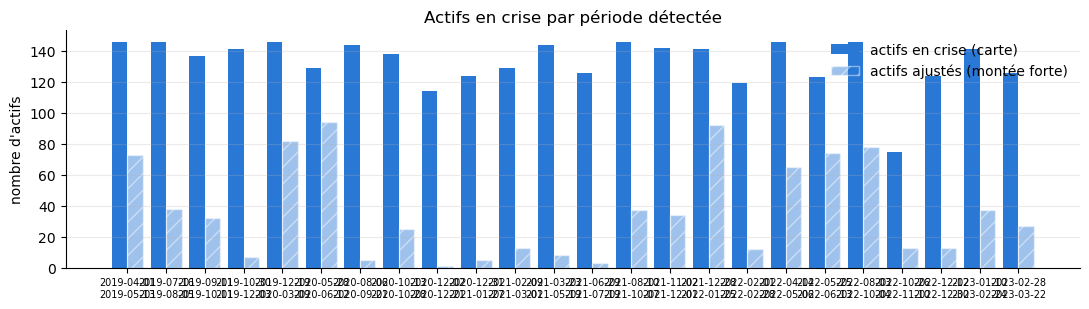

In [6]:
COLORS = {"PMFG": "#2a78d6", "VAR(1)": "#008300",
          "VAR(13)": "#e87ba4", "Corr thr": "#eda100"}
short = [labels[iv].replace(" → ", "\n") for iv in intervals]

fig, ax = plt.subplots(figsize=(11, 3.2))
x = np.arange(len(intervals))
n_crise = [n_crisis_assets(pa, pb) for (pa, pb) in intervals]
n_fit = [local[iv]["n_fit"] for iv in intervals]
ax.bar(x - 0.2, n_crise, 0.4, color="#2a78d6", label="actifs en crise (carte)")
ax.bar(x + 0.2, n_fit, 0.4, color="#2a78d6", alpha=0.45, hatch="//",
       edgecolor="white", label="actifs ajustés (montée forte)")
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=7)
ax.set_ylabel("nombre d'actifs")
ax.set_title("Actifs en crise par période détectée")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

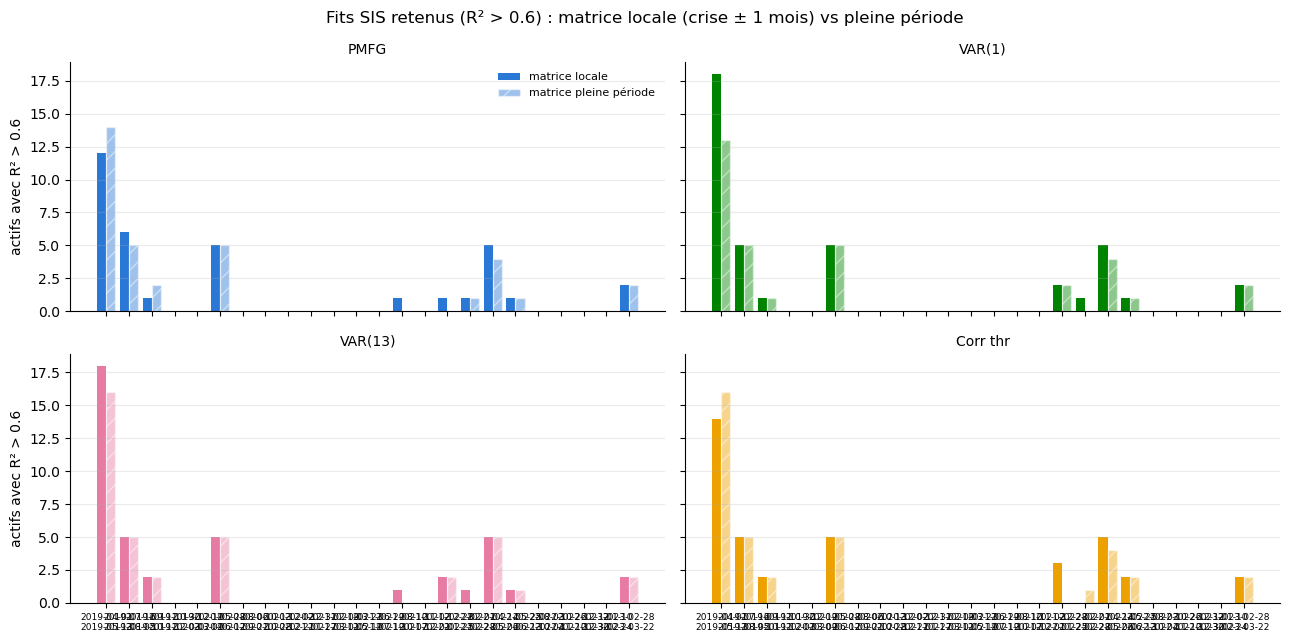

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True, sharey=True)
for ax, m in zip(axes.ravel(), config.SIS_MODELS):
    sub = df[df.methode == m].set_index("periode").loc[[labels[iv] for iv in intervals]]
    ax.bar(x - 0.2, sub["n_R2_local"], 0.4, color=COLORS[m], label="matrice locale")
    ax.bar(x + 0.2, sub["n_R2_global"], 0.4, color=COLORS[m], alpha=0.45,
           hatch="//", edgecolor="white", label="matrice pleine période")
    ax.set_title(m, fontsize=10)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[1]:
    ax.set_xticks(x); ax.set_xticklabels(short, fontsize=6.5)
for ax in axes[:, 0]:
    ax.set_ylabel("actifs avec R² > 0.6")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Fits SIS retenus (R² > 0.6) : matrice locale (crise ± 1 mois) vs pleine période")
plt.tight_layout(); plt.show()

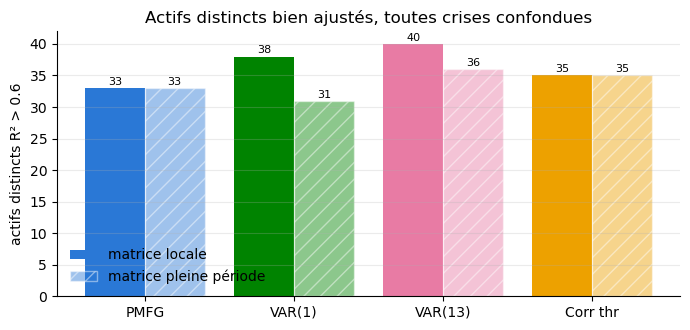

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.4))
xm = np.arange(len(config.SIS_MODELS))
loc = totaux["actifs_distincts_local"]
glo = totaux["actifs_distincts_global"]
bars_colors = [COLORS[m] for m in totaux.index]
ax.bar(xm - 0.2, loc, 0.4, color=bars_colors, label="matrice locale")
ax.bar(xm + 0.2, glo, 0.4, color=bars_colors, alpha=0.45, hatch="//",
       edgecolor="white", label="matrice pleine période")
for i, (l, g) in enumerate(zip(loc, glo)):
    ax.text(i - 0.2, l + 0.5, str(int(l)), ha="center", fontsize=8)
    ax.text(i + 0.2, g + 0.5, str(int(g)), ha="center", fontsize=8)
ax.set_xticks(xm); ax.set_xticklabels(totaux.index)
ax.set_ylabel("actifs distincts R² > 0.6")
ax.set_title("Actifs distincts bien ajustés, toutes crises confondues")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Encore plus local : crise ± 10 j, ± 5 j, crise seule

Même protocole, en resserrant la fenêtre de construction des matrices.
Attention à la statistique : la plus courte crise fait 12 jours, soit ~156
observations 30 min pour 146 actifs — à ± 0 le VAR (147 régresseurs) devient
sous-déterminé (solution moindre-norme de ``lstsq``) et la corrélation
empirique est très bruitée. C'est justement ce que ce balayage teste.

In [9]:
MARGINS = [21, 10, 5, 0]
locals_by_margin = {21: local}
for mg in MARGINS[1:]:
    locals_by_margin[mg] = compute_margin(mg)

for mg in MARGINS:
    T = [r["T_loc"] for r in locals_by_margin[mg].values()]
    print(f"± {mg:>2} j : T_loc min = {min(T):>5} obs, médian = {int(np.median(T))} "
          f"(N = 146 actifs, VAR : 147 régresseurs)")

[cache] OK  sis_local_m10
[cache] OK  sis_local_m5
[cache] OK  sis_local_m0
± 21 j : T_loc min =   662 obs, médian = 770 (N = 146 actifs, VAR : 147 régresseurs)
± 10 j : T_loc min =   410 obs, médian = 497 (N = 146 actifs, VAR : 147 régresseurs)
±  5 j : T_loc min =   286 obs, médian = 367 (N = 146 actifs, VAR : 147 régresseurs)
±  0 j : T_loc min =   156 obs, médian = 240 (N = 146 actifs, VAR : 147 régresseurs)


In [10]:
def _totaux(fits_by_iv, windows=None):
    """Par méthode : actifs distincts R²>seuil, nb de fits R²>seuil, R² moyen."""
    out = {}
    for m in config.SIS_MODELS:
        assets, r2s = set(), []
        for iv in (intervals if windows is None else windows):
            for gi, d in fits_by_iv(iv, m):
                r2s.append(d["r2"])
                if d["r2"] > config.R2_SEUIL:
                    assets.add(gi)
        r2s = np.array(r2s)
        out[m] = dict(actifs=len(assets), n_fits=int((r2s > config.R2_SEUIL).sum()),
                      R2_moyen=float(r2s.mean()))
    return out

ordre = ["± 0 j", "± 5 j", "± 10 j", "± 21 j", "pleine période"]
comp = {}
for mg in MARGINS:
    comp[f"± {mg} j"] = _totaux(lambda iv, m: locals_by_margin[mg][iv]["fits"][m].items())
comp["pleine période"] = _totaux(lambda iv, m: period_data[iv][1][m][1].items())

tbl = pd.concat({k: pd.DataFrame(v).T for k, v in comp.items()}, axis=0)
tbl = tbl.reindex([(k, m) for k in ordre for m in config.SIS_MODELS])
tbl.index.names = ["fenêtre", "méthode"]
tbl.astype({"actifs": int, "n_fits": int}).round(3)

actifs  n_fits  R2_moyen
fenêtre        méthode                           
± 0 j          PMFG          35      37     0.228
               VAR(1)        41      43     0.236
               VAR(13)       39      39     0.236
               Corr thr      36      38     0.229
± 5 j          PMFG          34      35     0.227
               VAR(1)        40      42     0.236
               VAR(13)       40      41     0.236
               Corr thr      37      39     0.230
± 10 j         PMFG          34      35     0.227
               VAR(1)        40      42     0.236
               VAR(13)       40      42     0.236
               Corr thr      36      38     0.229
± 21 j         PMFG          33      35     0.226
               VAR(1)        38      40     0.234
               VAR(13)       40      42     0.235
               Corr thr      35      38     0.231
pleine période PMFG          33      34     0.228
               VAR(1)        31      33     0.224
               VAR(13)       36      38     0.229
               Corr thr      35      37     0.230

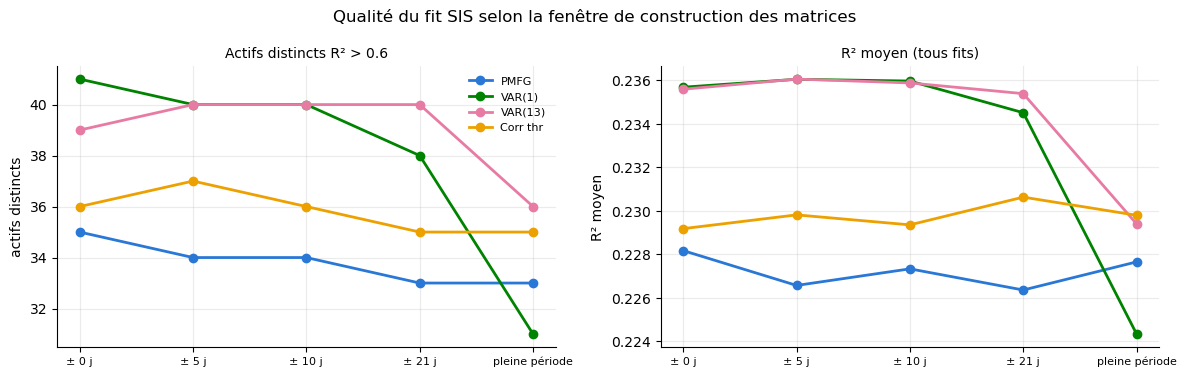

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
xo = np.arange(len(ordre))
for m in config.SIS_MODELS:
    ax1.plot(xo, [comp[k][m]["actifs"] for k in ordre], "-o", lw=2, ms=6,
             color=COLORS[m], label=m)
    ax2.plot(xo, [comp[k][m]["R2_moyen"] for k in ordre], "-o", lw=2, ms=6,
             color=COLORS[m], label=m)
for ax, t, yl in ((ax1, "Actifs distincts R² > 0.6", "actifs distincts"),
                  (ax2, "R² moyen (tous fits)", "R² moyen")):
    ax.set_xticks(xo); ax.set_xticklabels(ordre, fontsize=8)
    ax.set_title(t, fontsize=10); ax.set_ylabel(yl)
    ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False, fontsize=8)
fig.suptitle("Qualité du fit SIS selon la fenêtre de construction des matrices")
plt.tight_layout(); plt.show()

## 6. Même balayage sur les 17 montées de pics

Les comptes de référence de `synthese` / du rapport (p. ex. **79** bons fits
pour VAR(13)) sont établis sur les **montées des pics** de ⟨|C_ij|⟩ — des
fenêtres taillées sur la phase de montée vers le pic — et non sur les fenêtres
chronologiques. On refait donc le balayage local sur ces 17 montées, avec les
conditions initiales du cache `peak_period_data` (protocole identique).

In [12]:
pk = pipeline.fit_peaks(ctx, crisis_map)
peak_rises = [tuple(w) for w in pk["peak_rises"]]
peak_pd = pk["peak_pd"]
print(f"{len(peak_rises)} montées de pics, de "
      f"{min(b - a + 1 for a, b in peak_rises)} à {max(b - a + 1 for a, b in peak_rises)} jours")


def compute_margin_peaks(margin):
    """Fits SIS locaux (montée ± margin) pour les 17 montées de pics (caché)."""
    sig = sig_of(peak_rises, crisis_map, margin, config.CORR_THRESHOLD, config.T_LONG,
                 config.B_FIT, config.R_FIT, config.TOL_EQ, "local_A_fast")
    return disk_cache(f"sis_local_peaks_m{margin}", sig, lambda: dict(zip(
        peak_rises,
        Parallel(n_jobs=min(len(peak_rises), os.cpu_count()))(
            delayed(fits_local)(pa, pb, peak_pd[(pa, pb)][0], margin)
            for (pa, pb) in peak_rises))))


peaks_by_margin = {mg: compute_margin_peaks(mg) for mg in MARGINS}

[cache] OK  peak_period_data
17 montées de pics, de 13 à 57 jours


[cache] ..  sis_local_peaks_m21 calculé en 246.7s


[cache] ..  sis_local_peaks_m10 calculé en 232.3s


[cache] ..  sis_local_peaks_m5 calculé en 197.3s


[cache] ..  sis_local_peaks_m0 calculé en 229.8s


In [13]:
comp_pk = {}
for mg in MARGINS:
    comp_pk[f"± {mg} j"] = _totaux(
        lambda iv, m: peaks_by_margin[mg][iv]["fits"][m].items(), windows=peak_rises)
comp_pk["pleine période"] = _totaux(
    lambda iv, m: peak_pd[iv][1][m][1].items(), windows=peak_rises)

tbl_pk = pd.concat({k: pd.DataFrame(v).T for k, v in comp_pk.items()}, axis=0)
tbl_pk = tbl_pk.reindex([(k, m) for k in ordre for m in config.SIS_MODELS])
tbl_pk.index.names = ["fenêtre", "méthode"]
tbl_pk.astype({"actifs": int, "n_fits": int}).round(3)

actifs  n_fits  R2_moyen
fenêtre        méthode                           
± 0 j          PMFG          63      75     0.267
               VAR(1)        68      79     0.276
               VAR(13)       69      81     0.276
               Corr thr      65      76     0.268
± 5 j          PMFG          65      77     0.267
               VAR(1)        69      82     0.276
               VAR(13)       68      81     0.276
               Corr thr      66      77     0.268
± 10 j         PMFG          64      75     0.266
               VAR(1)        69      82     0.275
               VAR(13)       70      82     0.276
               Corr thr      61      74     0.267
± 21 j         PMFG          66      76     0.266
               VAR(1)        68      80     0.274
               VAR(13)       68      80     0.275
               Corr thr      60      72     0.267
pleine période PMFG          64      73     0.267
               VAR(1)        61      71     0.262
               VAR(13)       68      79     0.269
               Corr thr      65      75     0.268

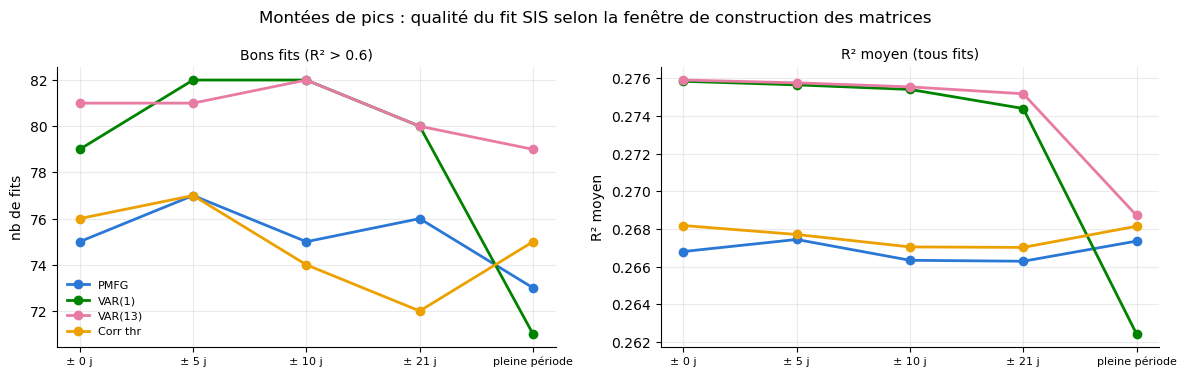

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
for m in config.SIS_MODELS:
    ax1.plot(xo, [comp_pk[k][m]["n_fits"] for k in ordre], "-o", lw=2, ms=6,
             color=COLORS[m], label=m)
    ax2.plot(xo, [comp_pk[k][m]["R2_moyen"] for k in ordre], "-o", lw=2, ms=6,
             color=COLORS[m], label=m)
for ax, t, yl in ((ax1, "Bons fits (R² > 0.6)", "nb de fits"),
                  (ax2, "R² moyen (tous fits)", "R² moyen")):
    ax.set_xticks(xo); ax.set_xticklabels(ordre, fontsize=8)
    ax.set_title(t, fontsize=10); ax.set_ylabel(yl)
    ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False, fontsize=8)
fig.suptitle("Montées de pics : qualité du fit SIS selon la fenêtre de construction des matrices")
plt.tight_layout(); plt.show()

## Lecture

**Fenêtres chronologiques (24 crises, sections 1-5).** Actifs distincts avec
R² > 0.6, de la pleine période à la crise seule (± 0 j) :
VAR(1) 31 → 38 → 40 → 40 → 41 ; VAR(13) 36 → 40 → 40 → 40 → 39 ;
PMFG 33 → 33 → 34 → 34 → 35 ; Corr thr 35 → 35 → 36 → 37 → 36.
R² moyens ~0.23 partout.

**Montées de pics (17 montées, section 6)** — le jeu de périodes de référence
de `synthese` (79 bons fits VAR(13) en pleine période, retrouvés ici).
Bons fits (R² > 0.6), pleine période → ± 21 → ± 10 → ± 5 → ± 0 j :
VAR(1) 71 → 80 → 82 → 82 → 79 ; VAR(13) 79 → 80 → 82 → 81 → 81 ;
PMFG 73 → 76 → 75 → 77 → 75 ; Corr thr 75 → 72 → 74 → 77 → 76.
R² moyens 0.26-0.28 (+0.01 pour les VAR locaux).

Dans les deux jeux de périodes, même verdict :

- **les matrices locales aident un peu, surtout le VAR(1)** (+7 à +11 fits) —
  ses coefficients captent une causalité propre à la période ; PMFG et
  Corr thr, dominés par la corrélation moyenne très stable, bougent à peine ;
- **le degré de localité est indifférent** : tout le gain est acquis dès
  ± 21 j, la courbe est plate jusqu'à ± 0 j ;
- **même la fenêtre minimale ne dégrade rien** (à ± 0 j, 156 obs pour 146
  actifs : corrélation bruitée, VAR sous-déterminé en moindre-norme) ;
- les montées de pics donnent ~2x plus de bons fits que les fenêtres
  chronologiques : c'est le choix des fenêtres temporelles (phase de montée),
  pas la matrice, qui fait la différence.

Conclusion : cohérent avec la restriction aux actifs en crise et le test A du
§9 de synthese — le fit SIS ↔ E_i est porté par les conditions initiales et le
profil E_i de la période ; la matrice de contagion n'y contribue que
marginalement, qu'elle soit locale ou pleine période.